In [1]:
%%time
from ToyMaker import *
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CPU times: user 938 ms, sys: 1.05 s, total: 1.98 s
Wall time: 1.39 s


CPU times: user 562 ms, sys: 0 ns, total: 562 ms
Wall time: 572 ms
CPU times: user 562 ms, sys: 0 ns, total: 562 ms
Wall time: 576 ms


90.32

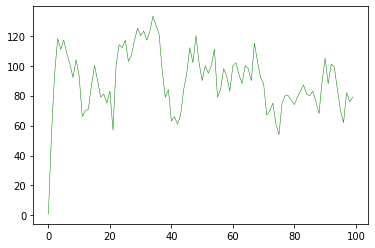

In [2]:
%%time
%%time

v = 50
α = 10
n = -2
γm = 1/15
γp = 1
kp = 10

def d_km(P):
    return (v*pow(P, n))/(pow(P, n) + pow(α, n))

def d_gamma_m(m):
    return γm * m

def d_kp(m):
    return kp * m

def d_gamma_p(P):
    return γp * P

species = {'t': 0., 'cell': 0,'P': 1., 'm': 1.}
reactions = {d_km: {'create': ['m']},
            d_gamma_m: {'destroy': ['m']},
            d_kp: {'create': ['P']},
            d_gamma_p: {'destroy': ['P']}}

tmax = 100
sampling_time = 1

cell = Cell(species, reactions, tmax, sampling_time);
plt.plot(cell[:, 0], cell[:, 2], 'g-', lw=0.5)
cell[:, 2].mean()

In [3]:
%%time
samples = 2
cells = multiple_Cells(species, reactions, tmax, sampling_time, cells=samples);

100%|██████████| 2/2 [00:00<00:00, 11.18it/s]


CPU times: user 15.6 ms, sys: 62.5 ms, total: 78.1 ms
Wall time: 722 ms


CPU times: user 0 ns, sys: 0 ns, total: 0 ns
Wall time: 5.48 µs


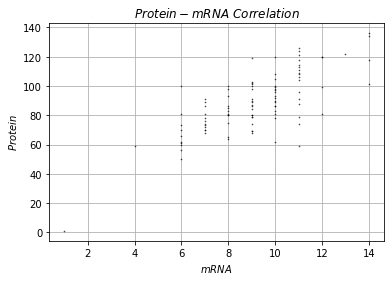

In [5]:
%time
[plt.plot(cells[i][:,3],cells[i][:, 2], 'o',lw=0.1, color='black', ms=0.5, label='Protein Levels', alpha=0.5) for i in range(samples)];
plt.xlabel(f'$mRNA$');
plt.ylabel(f'$Protein$');
plt.grid(True);
plt.title(f'$Protein-mRNA$ $Correlation$');

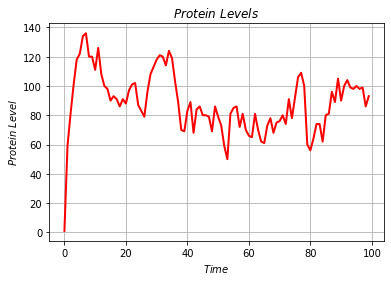

In [6]:
mean_arr = get_mean_per_cell(cells, samples, tmax, 2)
var_arr = get_variance_per_cell(cells, samples, tmax, 2)
noise = calculate_noise(mean_arr.mean(), var_arr.mean())

plt.plot(mean_arr, 'r-', lw=2);
[plt.plot(cells[i][:,0],cells[i][:, 2], '-',lw=0.5, color='grey', label='Protein Levels', alpha=0.01) for i in range(samples)];
plt.grid(True);
plt.title(f'$Protein$ $Levels$');
plt.xlabel(f'$Time$');
plt.ylabel(f'$Protein$ $Level$');

In [7]:
import pandas as pd
import numpy as np
from concurrent.futures import ProcessPoolExecutor

In [8]:
def Cell(species, reactions, tmax, sampling_time, cell=1, deterministic=False):

    species_names = get_species_names(species)

    reaction_type = set_reactions(reactions, species_names)

    system, system_parameters, system_idx = get_funct_get_pams(species)
    propensities, propensities_parameters, params_idx = get_funct_get_pams(reactions)

    species = set_values(species)
    reactions = set_values(reactions)

    species_index = get_index(species_names, system_parameters, system)
    reactions_species_index = get_index(species_names, propensities_parameters, propensities)

    tarr = np.arange(0, tmax , sampling_time ,dtype=float) 
    sim = setup_sim(tarr, species, cell)

    for i in range(1,len(tarr)):
        sim[i] = Gillespie(sim[i - 1], round(tarr[i], 4), reaction_type, propensities, system, species_index, reactions_species_index, system_idx, deterministic)
        sim[i][0] = round(sim[i][0], 6)
    return sim
     

def Gillespie(species, tmax, reaction_type, propensities, system, species_index, reactions_species_index, system_idx, deterministic):
    
    τ = species[0]

    while species[0] < tmax:

        τarr = solve_deterministic_model(system, species, species_index, system_idx) if deterministic == True else []
        τarr = calculate_propensities(propensities, species, reactions_species_index)
        τ,  q = minimal_value(τarr)
        species = species + reaction_type[q]
        species[0] = species[0] + τ

    return species

In [9]:
%%time
import warnings
def multiple_cells_by_batch(species, reactions, tmax, sampling_time, samples=10, deterministic=False, batch_size=10):
    cells = [i * batch_size for i in range(samples)]
    columns = list(species.keys())
    for i in tqdm(range(samples)):
        cells_arr = []
        with ProcessPoolExecutor() as executor:
            warnings.simplefilter("ignore")
            cells_arr = [executor.submit(Cell, species, reactions, tmax, sampling_time, c + 1, deterministic) for c in range(cells[i], cells[i + 1] if i + 1 < samples else cells[i] + batch_size)]
            cells_arr = [c.result() for c in cells_arr]
            cells_arr = np.array(cells_arr)
            cells_arr = np.concatenate(cells_arr, axis=0)
            cells_arr = pd.DataFrame(cells_arr, columns=columns, dtype=float)
            with open('all_dfs.csv', 'a') as f: cells_arr.to_csv(f, index=False)

multiple_cells_by_batch(species, reactions, 10, sampling_time, samples=10, batch_size=5)

100%|██████████| 10/10 [00:02<00:00,  3.90it/s]

CPU times: user 156 ms, sys: 1.47 s, total: 1.62 s
Wall time: 2.57 s


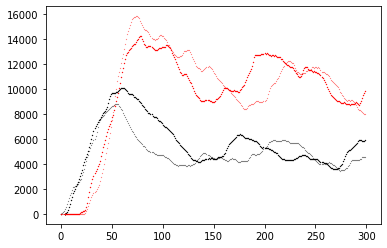

In [10]:
import matplotlib.pyplot as plt

cells = pd.read_csv('Toy_model.csv')
# cells['p2'].plot.hist(bins=30, lw=0.5, color='green', label='Protein Levels', alpha=0.5);
plt.plot(cells['t'], cells['p2'], 'o',lw=0.1, color='black', ms=0.1, label='Protein Levels')
plt.plot(cells['t'], cells['p1'], 'o',lw=0.1, color='red', ms=0.1, label='Protein Levels')
# print(cells['cell'].unique())